# Olist Gold-Layer Business Analytics

All analysis is done in **Spark SQL** against the gold-layer tables. Results are converted to
pandas (`.toPandas()`) only at the final, already-aggregated step, purely for charting.

**Marts:**
1. Seller performance & risk scorecard
2. Customer RFM segmentation
3. Cohort retention analysis
4. Business impact projection — win-back opportunity sizing (see final section for methodology & caveats)

In [1]:
from pyspark.sql import SparkSession
import pandas as pd
import matplotlib.pyplot as plt
import os

spark = SparkSession.builder \
    .appName("Ecommerce-Gold-Analytics") \
    .master("local[*]") \
    .getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

chart_dir = "analytics_exports/dashboard/charts"
os.makedirs(chart_dir, exist_ok=True)
os.makedirs("analytics_exports/dashboard", exist_ok=True)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Spark session started.")

Spark session started.


## Load gold tables (single read, Spark only)

In [2]:
fact_order_items = spark.read.parquet("gold/fact_order_items")
dim_customers = spark.read.parquet("gold/dim_customers")

fact_order_items.createOrReplaceTempView("fact_order_items")
dim_customers.createOrReplaceTempView("dim_customers")

print("Row counts —",
"fact_order_items:", fact_order_items.count(),
"| dim_customers:", dim_customers.count())

Row counts — fact_order_items: 112650 | dim_customers: 99441


## Mart 1 — Seller performance & risk scorecard

Composite risk score = late-delivery rate + (cancellation rate × 2). Cancellations are weighted
higher because a cancelled order is a stronger reliability signal than a late one.

In [4]:
seller_risk_sql = """
WITH seller_orders AS (
    SELECT
        seller_id,
        order_id,
        ROUND(SUM(price), 2) AS order_revenue,
        MAX(order_status) AS order_status,
        MAX(delivery_days) AS delivery_days,
        MAX(CASE WHEN is_late = TRUE THEN 1 ELSE 0 END) AS is_late
    FROM fact_order_items
    GROUP BY seller_id, order_id
),
seller_metrics AS (
    SELECT
        seller_id,
        COUNT(*) AS total_orders,
        ROUND(SUM(order_revenue), 2) AS total_revenue,
        ROUND(AVG(delivery_days), 1) AS avg_delivery_days,
        ROUND(100.0 * SUM(is_late) / COUNT(*), 2) AS late_rate_pct,
        ROUND(100.0 * SUM(CASE WHEN order_status = 'canceled' THEN 1 ELSE 0 END) / COUNT(*), 2) AS cancel_rate_pct
    FROM seller_orders
    GROUP BY seller_id
    HAVING COUNT(*) >= 10
)
SELECT *,
    ROUND(late_rate_pct + (cancel_rate_pct * 2.0), 2) AS composite_risk_score,
    CASE
        WHEN late_rate_pct + (cancel_rate_pct * 2.0) >= 60 THEN 'High'
        WHEN late_rate_pct + (cancel_rate_pct * 2.0) >= 30 THEN 'Medium'
        ELSE 'Low'
    END AS risk_category
FROM seller_metrics
ORDER BY composite_risk_score DESC
"""

seller_scorecard = spark.sql(seller_risk_sql)
seller_scorecard.createOrReplaceTempView("seller_scorecard")
seller_scorecard.show(10, truncate=False)

+--------------------------------+------------+-------------+-----------------+-------------+---------------+--------------------+-------------+
|seller_id                       |total_orders|total_revenue|avg_delivery_days|late_rate_pct|cancel_rate_pct|composite_risk_score|risk_category|
+--------------------------------+------------+-------------+-----------------+-------------+---------------+--------------------+-------------+
|81783131d2a97c8d44d406a4be81b5d9|13          |1782.54      |7.0              |7.69         |38.46          |84.61               |High         |
|b1b3948701c5c72445495bd161b83a4c|18          |24699.19     |23.4             |50.00        |11.11          |72.22               |High         |
|973f21788dfab357250f69a8dcb7ddee|10          |909.0        |23.6             |50.00        |10.00          |70.00               |High         |
|20b54c376b794ed028df09a3cd88e8dc|11          |1342.95      |21.1             |18.18        |18.18          |54.54               |

In [8]:
# Convert only the small, already-aggregated result to pandas for export + charting
seller_pd = seller_scorecard.toPandas()
seller_pd.to_csv("analytics_exports/seller_scorecard.csv", index=False)
top10_sellers = seller_pd.head(10)
top10_sellers.to_csv("analytics_exports/dashboard/top_seller_risk.csv", index=False)
print("Seller scorecard exported.")

Seller scorecard exported.


## Mart 2 — Customer RFM segmentation

Recency, frequency, and monetary scoring done entirely in Spark SQL using `NTILE(4)` window
functions — no `pandas.qcut` needed.

In [6]:
rfm_sql = """
WITH customer_base AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT f.order_id) AS frequency,
        ROUND(SUM(f.price), 2) AS monetary,
        MAX(f.order_purchase_timestamp) AS last_purchase_date
    FROM fact_order_items f
    JOIN dim_customers c ON f.customer_id = c.customer_id
    WHERE f.order_status = 'delivered'
    GROUP BY c.customer_unique_id
),
with_recency AS (
    SELECT *,
        DATEDIFF(
            (SELECT MAX(last_purchase_date) FROM customer_base),
            last_purchase_date
        ) AS recency_days
    FROM customer_base
),
scored AS (
    SELECT *,
        NTILE(4) OVER (ORDER BY monetary ASC) AS m_score,
        NTILE(4) OVER (ORDER BY recency_days DESC) AS r_score
    FROM with_recency
)
SELECT *,
    CASE
        WHEN r_score >= 3 AND m_score >= 3 THEN 'Recent High-Value'
        WHEN r_score < 3  AND m_score >= 3 THEN 'Lapsed High-Value'
        WHEN frequency > 1 THEN 'Repeat Loyalists'
        ELSE 'Low-Value One-Time'
    END AS segment_name
FROM scored
"""

customer_segments = spark.sql(rfm_sql)
customer_segments.createOrReplaceTempView("customer_segments")

segment_summary_sql = """
SELECT
    segment_name,
    COUNT(*) AS customers,
    ROUND(SUM(monetary), 2) AS revenue,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS customer_share_pct,
    ROUND(100.0 * SUM(monetary) / SUM(SUM(monetary)) OVER (), 2) AS revenue_share_pct,
    ROUND(AVG(monetary), 2) AS avg_monetary_per_customer
FROM customer_segments
GROUP BY segment_name
ORDER BY revenue DESC
"""

segment_summary = spark.sql(segment_summary_sql)
segment_summary.show(truncate=False)

+------------------+---------+----------+------------------+-----------------+-------------------------+
|segment_name      |customers|revenue   |customer_share_pct|revenue_share_pct|avg_monetary_per_customer|
+------------------+---------+----------+------------------+-----------------+-------------------------+
|Recent High-Value |23600    |5556234.68|25.28             |42.02            |235.43                   |
|Lapsed High-Value |23078    |5458910.12|24.72             |41.29            |236.54                   |
|Low-Value One-Time|46222    |2177945.0 |49.51             |16.47            |47.12                    |
|Repeat Loyalists  |458      |28408.31  |0.49              |0.21             |62.03                    |
+------------------+---------+----------+------------------+-----------------+-------------------------+



In [9]:
segment_pd = segment_summary.toPandas()
segment_pd.to_csv("analytics_exports/dashboard/segment_summary.csv", index=False)
customer_segments.toPandas().to_csv("analytics_exports/customer_segmentation.csv", index=False)
print("Segmentation exported.")

Segmentation exported.


## Mart 3 — Cohort retention analysis

Months-since-first-purchase cohort logic, done as a self-join + window function in Spark SQL.

In [5]:
#for Lapsed High-Value customers: was their most recent order a bad experience?
#(bad review, late delivery, or cancelled) vs neutral (they just went quiet)
result7 = spark.sql("""
WITH customer_last_order AS (

SELECT
    c.customer_unique_id,
    f.order_id,
    f.order_purchase_timestamp,
    f.order_status,
    f.is_late,
    f.review_score,
    ROW_NUMBER() OVER (
        PARTITION BY c.customer_unique_id
        ORDER BY f.order_purchase_timestamp DESC
    ) AS rn

FROM fact_order_items f
JOIN dim_customers c ON f.customer_id = c.customer_id

)

SELECT
    cs.customer_unique_id,
    cs.monetary,
    clo.review_score,
    clo.is_late,
    clo.order_status,
    CASE
        WHEN clo.review_score <= 2 THEN TRUE
        WHEN clo.is_late = TRUE THEN TRUE
        WHEN clo.order_status = 'canceled' THEN TRUE
        ELSE FALSE
    END AS lapse_bucket_bad_experience

FROM customer_segments cs
JOIN customer_last_order clo
    ON cs.customer_unique_id = clo.customer_unique_id
    AND clo.rn = 1

WHERE cs.segment_name = 'Lapsed High-Value';
""")
result7.createOrReplaceTempView("lapsed_detail")
result7.show(10)

+--------------------+--------+------------+-------+------------+---------------------------+
|  customer_unique_id|monetary|review_score|is_late|order_status|lapse_bucket_bad_experience|
+--------------------+--------+------------+-------+------------+---------------------------+
|0005e1862207bf6cc...|   135.0|           4|  false|   delivered|                      false|
|0011c98589159d614...|   99.99|           5|  false|   delivered|                      false|
|002cdf87d4c03f08f...|  196.99|           1|   true|   delivered|                       true|
|002d71b244beb91ca...|   115.0|           5|  false|   delivered|                      false|
|004288347e5e88a27...|  317.89|           5|  false|   delivered|                      false|
|005ff4ebe100db3ee...|   199.9|           5|  false|   delivered|                      false|
|00776f3807b128bec...|  294.99|           3|  false|   delivered|                      false|
|007953b3182d5ccc9...|   99.99|           1|   true|   deliv

In [11]:
cohort_sql = """
WITH customer_orders AS (
    SELECT
        c.customer_unique_id,
        f.order_id,
        DATE_TRUNC('month', f.order_purchase_timestamp) AS purchase_month
    FROM fact_order_items f
    JOIN dim_customers c ON f.customer_id = c.customer_id
    WHERE f.order_status = 'delivered'
    GROUP BY c.customer_unique_id, f.order_id, DATE_TRUNC('month', f.order_purchase_timestamp)
),
cohorts AS (
    SELECT *,
        MIN(purchase_month) OVER (PARTITION BY customer_unique_id) AS cohort_month,
        CAST(MONTHS_BETWEEN(
            purchase_month,
            MIN(purchase_month) OVER (PARTITION BY customer_unique_id)
        ) AS INT) AS cohort_index
    FROM customer_orders
),
cohort_sizes AS (
    SELECT cohort_month, COUNT(DISTINCT customer_unique_id) AS cohort_size
    FROM cohorts WHERE cohort_index = 0
    GROUP BY cohort_month
)
SELECT
    c.cohort_month,
    c.cohort_index,
    s.cohort_size,
    COUNT(DISTINCT c.customer_unique_id) AS active_customers,
    ROUND(100.0 * COUNT(DISTINCT c.customer_unique_id) / s.cohort_size, 2) AS retention_pct
FROM cohorts c
JOIN cohort_sizes s ON c.cohort_month = s.cohort_month
GROUP BY c.cohort_month, c.cohort_index, s.cohort_size
ORDER BY c.cohort_month, c.cohort_index
"""

cohort_data = spark.sql(cohort_sql)
cohort_data.createOrReplaceTempView("cohort_data")

cohort_summary_sql = """
SELECT
    cohort_index,
    COUNT(DISTINCT cohort_month) AS cohorts,
    SUM(active_customers) AS total_active_customers,
    SUM(cohort_size) AS total_cohort_customers,
    ROUND(100.0 * SUM(active_customers) / SUM(cohort_size), 2) AS retention_pct
FROM cohort_data
WHERE cohort_index > 0
GROUP BY cohort_index
ORDER BY cohort_index
LIMIT 12
"""

cohort_summary = spark.sql(cohort_summary_sql)
cohort_summary.show(12)

+------------+-------+----------------------+----------------------+-------------+
|cohort_index|cohorts|total_active_customers|total_cohort_customers|retention_pct|
+------------+-------+----------------------+----------------------+-------------+
|           1|     20|                   421|                 86951|         0.48|
|           2|     18|                   273|                 81001|         0.34|
|           3|     17|                   192|                 75123|         0.26|
|           4|     16|                   176|                 68617|         0.26|
|           5|     15|                   140|                 62035|         0.23|
|           6|     15|                   129|                 55523|         0.23|
|           7|     13|                   102|                 48973|         0.21|
|           8|     12|                    86|                 42131|         0.20|
|           9|     11|                    60|                 36338|         0.17|
|   

In [12]:
#bucket summary: how many lapsed customers fall into each bucket, and how much revenue
result8 = spark.sql("""
SELECT
    CASE WHEN lapse_bucket_bad_experience THEN 'Bad Experience' ELSE 'Neutral / Forgot' END AS lapse_bucket,
    COUNT(*) AS customers,
    ROUND(SUM(monetary), 2) AS revenue,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_of_lapsed_segment
FROM lapsed_detail
GROUP BY lapse_bucket_bad_experience
ORDER BY customers DESC;
""")
result8.show()

+----------------+---------+----------+---------------------+
|    lapse_bucket|customers|   revenue|pct_of_lapsed_segment|
+----------------+---------+----------+---------------------+
|Neutral / Forgot|    19273|4463614.96|                83.51|
|  Bad Experience|     3805| 995295.16|                16.49|
+----------------+---------+----------+---------------------+



In [19]:
cohort_pd = cohort_summary.toPandas()
cohort_pd.to_csv("analytics_exports/dashboard/cohort_summary.csv", index=False)
cohort_data.toPandas().to_csv("analytics_exports/cohort_retention.csv", index=False)
print("Cohort retention exported.")

Cohort retention exported.


## Visualizations

Charts built from the pandas conversions above, saved as PNGs for the README/dashboard.

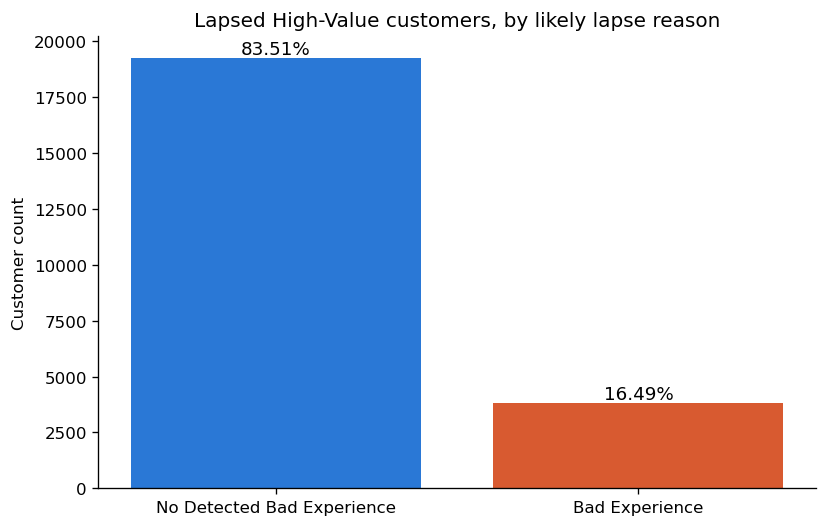

In [20]:
lapse_bucket_pd = result8.toPandas()
lapse_bucket_pd['lapse_bucket'] = lapse_bucket_pd['lapse_bucket'].replace(
    'Neutral / Forgot', 'No Detected Bad Experience'
)
lapse_bucket_pd.to_csv("analytics_exports/dashboard/lapse_reason_buckets.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ['#2a78d6', '#D85A30']
ax.bar(lapse_bucket_pd['lapse_bucket'], lapse_bucket_pd['customers'], color=colors)
ax.set_title('Lapsed High-Value customers, by likely lapse reason')
ax.set_ylabel('Customer count')
for i, row in lapse_bucket_pd.iterrows():
    ax.text(i, row['customers'], f"{row['pct_of_lapsed_segment']}%", ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig(f"{chart_dir}/lapse_reason_buckets.png", bbox_inches='tight')
plt.show()

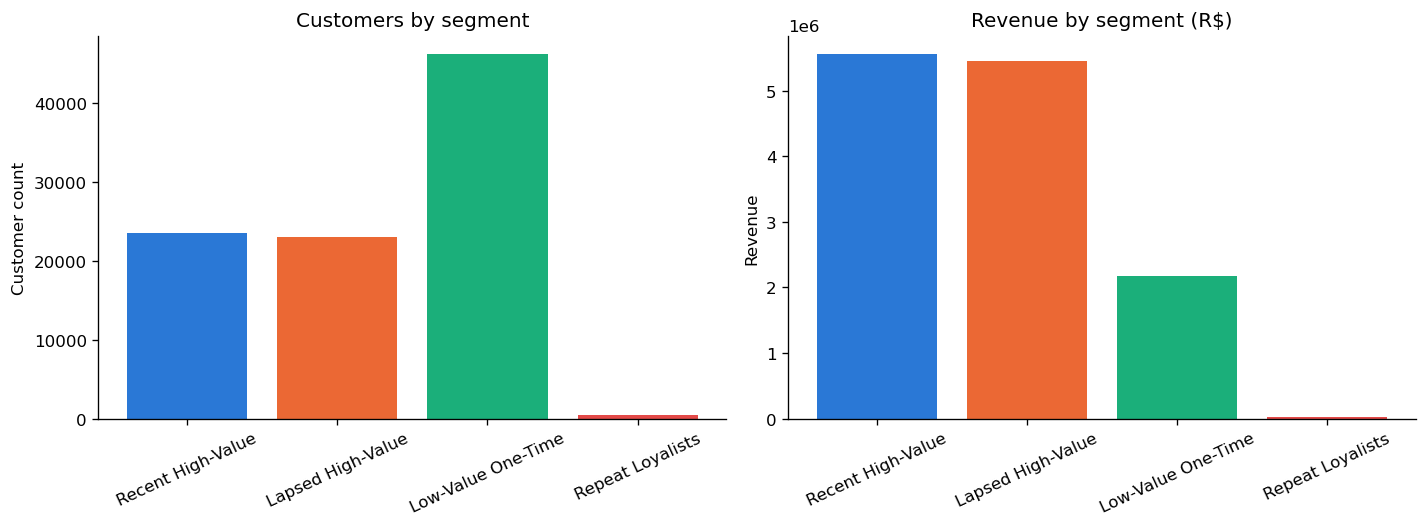

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ['#2a78d6', '#eb6834', '#1baf7a', '#e34948']

axes[0].bar(segment_pd['segment_name'], segment_pd['customers'], color=colors)
axes[0].set_title('Customers by segment')
axes[0].set_ylabel('Customer count')
axes[0].tick_params(axis='x', rotation=25)

axes[1].bar(segment_pd['segment_name'], segment_pd['revenue'], color=colors)
axes[1].set_title('Revenue by segment (R$)')
axes[1].set_ylabel('Revenue')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig(f"{chart_dir}/segment_summary.png", bbox_inches='tight')
plt.show()

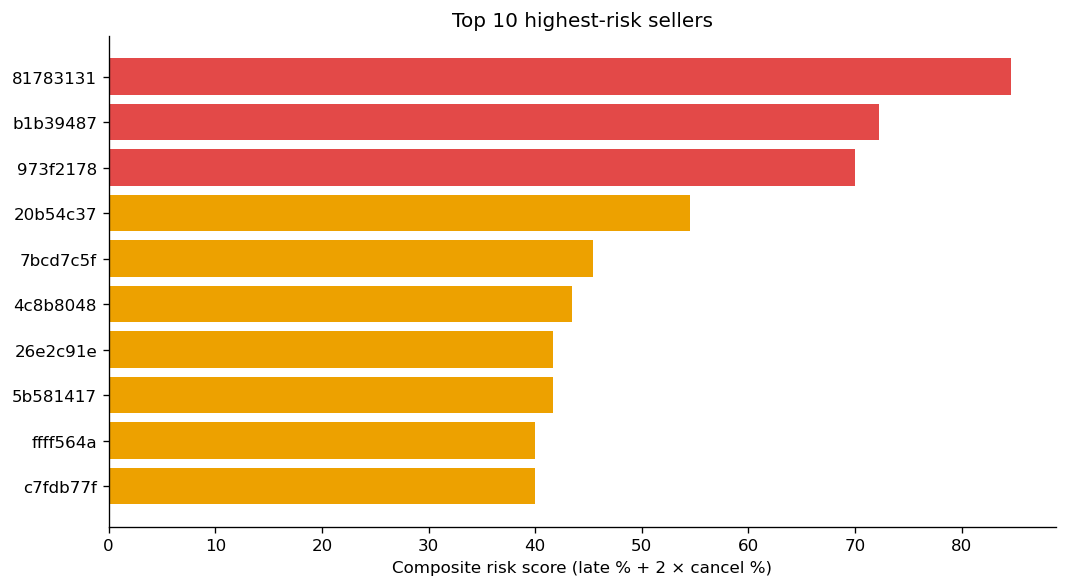

In [16]:
top10 = seller_pd.head(10).sort_values('composite_risk_score', ascending=True)
risk_colors = top10['risk_category'].map({'High': '#e34948', 'Medium': '#eda100', 'Low': '#1baf7a'})

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10['seller_id'].str[:8], top10['composite_risk_score'], color=risk_colors)
ax.set_xlabel('Composite risk score (late % + 2 × cancel %)')
ax.set_title('Top 10 highest-risk sellers')

plt.tight_layout()
plt.savefig(f"{chart_dir}/seller_risk.png", bbox_inches='tight')
plt.show()

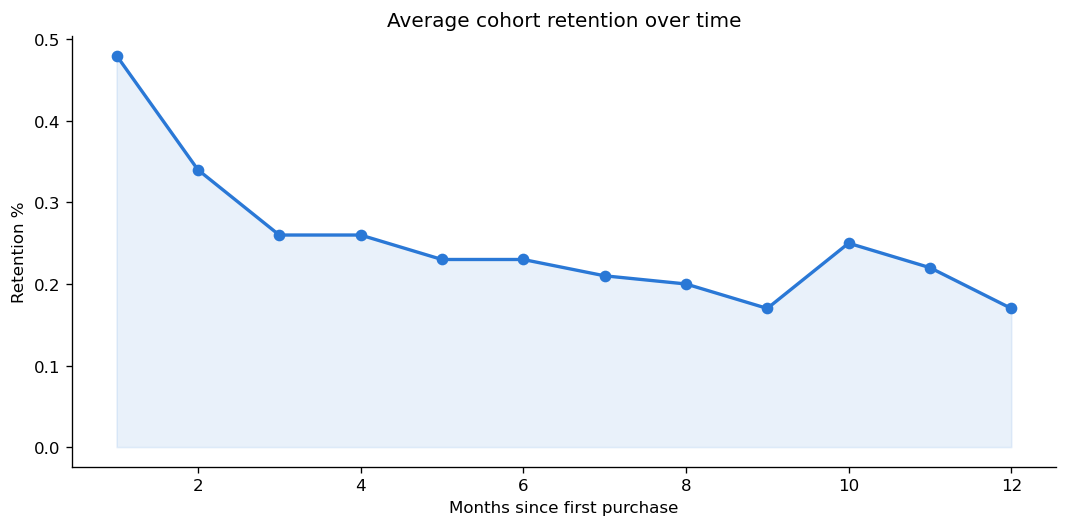

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(cohort_pd['cohort_index'], cohort_pd['retention_pct'], marker='o', color='#2a78d6', linewidth=2)
ax.fill_between(cohort_pd['cohort_index'], cohort_pd['retention_pct'], alpha=0.1, color='#2a78d6')
ax.set_xlabel('Months since first purchase')
ax.set_ylabel('Retention %')
ax.set_title('Average cohort retention over time')

plt.tight_layout()
plt.savefig(f"{chart_dir}/cohort_retention.png", bbox_inches='tight')
plt.show()

## Business impact projection — win-back campaign opportunity sizing

**What this is:** an estimate of the revenue opportunity if the business acts on the retention
finding above, sized using a published industry benchmark — not a measured outcome.

**What this is not:** proof that the campaign works. That can only come from actually running it
and comparing real before/after revenue for the targeted segment (ideally via an A/B test holding
out a control group). The numbers below are the business case for running that test, not a
substitute for it.

**Benchmark used:** published 2025–2026 e-commerce win-back campaign data (Klaviyo-sourced,
compiled by Eightx) reports program-level reactivation — lapsed customers returning through any
channel — averaging **12–20%** for a well-run campaign, distinct from the lower 2–5% figure that
measures single-email-touch conversion specifically. We use the 12–20% program-level range here
since a real win-back program uses a multi-touch sequence, not a single email.

In [14]:
# Target: the Lapsed High-Value segment — customers with historically high spend who haven't
# purchased recently. This is the group most worth a targeted win-back spend.

lapsed = segment_pd[segment_pd['segment_name'] == 'Lapsed High-Value'].iloc[0]

scenarios = pd.DataFrame({
    'scenario': ['Conservative (12% reactivation)', 'Optimistic (20% reactivation)'],
    'reactivation_rate': [0.12, 0.20]
})

scenarios['segment'] = 'Lapsed High-Value'
scenarios['segment_customers'] = lapsed['customers']
scenarios['avg_monetary_per_customer'] = lapsed['avg_monetary_per_customer']
scenarios['projected_reactivated_customers'] = (
    scenarios['segment_customers'] * scenarios['reactivation_rate']
).round(0).astype(int)

# Assume a reactivated customer places one order near their historical average order value —
# a conservative assumption, since a win-back offer often includes a discount that would
# reduce this slightly in practice.
scenarios['projected_incremental_revenue'] = (
    scenarios['projected_reactivated_customers'] * scenarios['avg_monetary_per_customer']
).round(2)

scenarios['current_segment_revenue'] = lapsed['revenue']
scenarios['projected_new_segment_revenue'] = (
    scenarios['current_segment_revenue'] + scenarios['projected_incremental_revenue']
).round(2)
scenarios['pct_lift_vs_current'] = (
    100 * scenarios['projected_incremental_revenue'] / scenarios['current_segment_revenue']
).round(2)

scenarios.to_csv("analytics_exports/dashboard/winback_projection.csv", index=False)
scenarios[['scenario', 'projected_reactivated_customers', 'projected_incremental_revenue',
           'projected_new_segment_revenue', 'pct_lift_vs_current']]

,scenario,projected_reactivated_customers,projected_incremental_revenue,projected_new_segment_revenue,pct_lift_vs_current
0,Conservative (12% reactivation),2769,654979.26,6113889.38,12.0
1,Optimistic (20% reactivation),4616,1091868.64,6550778.76,20.0


### How to actually prove this once implemented

1. Split the Lapsed High-Value segment into a treatment group (receives the win-back sequence)
   and a control group (receives nothing), matched on `avg_monetary_per_customer` and `recency_days`.
2. After the campaign window (30–45 days per the benchmark literature), measure actual
   `reactivation_rate` = customers in each group who placed a new order.
3. Compare treatment vs. control reactivation rate and revenue — the *difference* is the true
   causal effect, not the treatment group's raw number (some would have returned anyway).
4. Only once that comparison exists can this notebook's projected numbers be replaced with
   measured ones — at which point, add a `winback_results_actual.csv` alongside this projection
   and update `docs/business-insights.md` with the real lift.